In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías y de `listings_train.csv`/`listings_test.csv`, el split guardado por `03_model_baseline.ipynb` (mismo `random_state=42`, para que los resultados sean comparables entre notebooks).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/sevilla/listings_train.csv")
test_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/sevilla/listings_test.csv")
train_df.shape, test_df.shape

((6112, 78), (1528, 78))

## 2. ¿Qué modelos vamos a probar?

En el baseline, la regresión lineal se quedó muy corta (R²=0.06) y confirmó que `price` en Sevilla es especialmente difícil de explicar con un modelo lineal, por el motivo ya identificado (una cola alta que la EDA decidió no recortar). Con eso en mente, se prueban los mismos cuatro tipos de modelo que en las otras cuatro ciudades:

- **Ridge**: versión regularizada de la regresión lineal del baseline. Sirve para ver cuánto más se le puede sacar a un modelo lineal antes de pasar a algo no lineal.
- **Random Forest**: ensemble por *bagging* de árboles de decisión. Robusto, apenas necesita ajuste, no le afecta la escala ni la multicolinealidad. No admite `NaN`.
- **Extra Trees**: variante de Random Forest con aleatoriedad extra al elegir los cortes de cada árbol. Tampoco admite `NaN`.
- **Hist Gradient Boosting**: ensemble por *boosting* basado en histogramas, el sustituto de `scikit-learn` más parecido a XGBoost/LightGBM (que no se pudieron usar por el problema de `libomp`, igual que en las otras ciudades). Admite `NaN` nativamente.

Los cuatro se entrenan dentro de un `Pipeline`. Para Ridge/Random Forest/Extra Trees el pipeline incluye un paso de imputación (y de escalado, solo para Ridge). Para Hist Gradient Boosting no se imputa nada, para conservar la información de "sin reviews todavía" que aporta el propio `NaN`.

## 3. Preparación de X e y

Mismos identificadores, objetivo y columnas de fuga que en `03_model_baseline.ipynb`. A diferencia del baseline, aquí no se imputa nada todavía: eso queda dentro de cada `Pipeline`.

### 3.1 Identificadores, objetivo y columnas de fuga

In [3]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
leakage_cols = ["price_log", "price_per_accommodate", "price_per_min_night"]
feature_cols = [c for c in train_df.columns if c not in id_cols + [target_col] + leakage_cols]

len(feature_cols)

71

### 3.2 X e y

`train_df`/`test_df` ya son el split guardado por el baseline, así que aquí no hace falta volver a dividir nada.

In [4]:
X_train, y_train = train_df[feature_cols].copy(), train_df[target_col].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[target_col].copy()

X_train.shape, X_test.shape

((6112, 71), (1528, 71))

### 3.3 Booleanas a 0/1

In [5]:
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

len(bool_cols)

40

### 3.4 Nulos: sin tratar todavía

`review_scores_rating`, `listing_age_days` y `days_since_last_review` se quedan con sus `NaN` tal cual. Cada `Pipeline` de la sección 4 decide si los imputa o los deja pasar al modelo.

In [6]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

review_scores_rating      392
listing_age_days          392
days_since_last_review    392
dtype: int64

## 4. Pipelines

Un `Pipeline` por modelo, con el preprocesado que necesita cada uno.

### 4.1 Objetivo: `log1p(price)`

Mismo criterio que en el baseline: se entrena sobre `log1p(price)`, no sobre `price` directamente.

In [7]:
y_train_log = np.log1p(y_train)

### 4.2 Un `Pipeline` por modelo

In [8]:
pipelines = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Hist Gradient Boosting": Pipeline([
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]),
}

list(pipelines.keys())

['Ridge', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting']

Con hiperparámetros por defecto en los cuatro por ahora: el ajuste fino es la sección 6.

## 5. Entrenamiento y comparación entre modelos

Los cuatro pipelines evaluados por validación cruzada sobre el train (sin tocar el test todavía).

### 5.1 Función `evaluate` y validación cruzada manual

In [9]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 5.2 Comparar los cuatro con 5-fold CV

In [10]:
from sklearn.model_selection import KFold

def cv_evaluate(pipeline, X, y_log, name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        pipeline.fit(X_tr, y_tr_log)
        pred = np.expm1(pipeline.predict(X_val))
        y_val = np.expm1(y_val_log)
        scores.append(evaluate(y_val, pred, name))
    return pd.DataFrame(scores).drop(columns="modelo").mean()

cv_rows = []
for name, pipe in pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    cv_rows.append(scores)

cv_results = pd.DataFrame(cv_rows).set_index("modelo")
cv_results.round(3)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.p

,RMSE,MAE,R2,MAPE
modelo,,,,
Ridge,276.706,56.403,0.088,29.020
Random Forest,275.146,53.827,0.104,27.147
Extra Trees,275.786,53.159,0.099,26.564
Hist Gradient Boosting,271.744,52.623,0.127,26.531


### 5.3 Interpretación

Los cuatro quedan muy apretados y, sobre todo, muy bajos en euros: Ridge (R²=0.088), Random Forest (0.104), Extra Trees (0.099) y Hist Gradient Boosting (0.127, el mejor de los cuatro con hiperparámetros por defecto, igual que en Valencia). Encaja con lo ya visto en `03_model_baseline.ipynb`: en Sevilla, RMSE y R² en euros están dominados por un puñado de precios extremos, así que ni siquiera un modelo de árboles sin afinar puede sacar una ventaja grande todavía sobre esa métrica en concreto, aunque, como se verá en la sección 6, sí hay mucho margen de mejora en la escala logarítmica.

Como en las otras ciudades, esta comparación no decide nada: los tres modelos de árboles se afinan igualmente en la sección 6, no solo el que gane aquí por poco.

## 6. Ajuste de hiperparámetros

Se afinan Random Forest, Extra Trees y Hist Gradient Boosting con `RandomizedSearchCV` y validación cruzada.

`RandomizedSearchCV` con 15 combinaciones y 3 folds por modelo (45 entrenamientos cada uno), sobre `y_train_log` con `scoring="r2"`.

### 6.1 Random Forest

In [11]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    pipelines["Random Forest"], rf_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train_log)

print(rf_search.best_params_)
print(rf_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.5546837344096396


### 6.2 Extra Trees

In [12]:
et_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

et_search = RandomizedSearchCV(
    pipelines["Extra Trees"], et_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
et_search.fit(X_train, y_train_log)

print(et_search.best_params_)
print(et_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.5433986803661509


### 6.3 Hist Gradient Boosting

In [13]:
hgb_param_dist = {
    "model__max_iter": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__l2_regularization": [0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    pipelines["Hist Gradient Boosting"], hgb_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
hgb_search.fit(X_train, y_train_log)

print(hgb_search.best_params_)
print(hgb_search.best_score_)

{'model__max_leaf_nodes': 63, 'model__max_iter': 300, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
0.5745438231765149


### 6.4 Resumen

Los tres suben con fuerza en escala logarítmica: Random Forest a 0.555, Extra Trees a 0.543, Hist Gradient Boosting a **0.575**, el mejor de los tres. Ojo: este número está en la escala de `log1p(price)`, no es directamente comparable con la tabla en euros de la sección 5. La comparación justa en euros se hace en la sección 7.

## 7. Elegir el modelo final

Los tres modelos ya afinados, comparados entre sí (seguimos sin tocar el test).

### 7.1 Comparar en euros con los mejores hiperparámetros

In [14]:
from sklearn.base import clone

tuned_pipelines = {
    "Random Forest (tuned)": clone(rf_search.best_estimator_),
    "Extra Trees (tuned)": clone(et_search.best_estimator_),
    "Hist Gradient Boosting (tuned)": clone(hgb_search.best_estimator_),
}

tuned_rows = []
for name, pipe in tuned_pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    tuned_rows.append(scores)

tuned_results = pd.DataFrame(tuned_rows).set_index("modelo")
tuned_results.round(3)

,RMSE,MAE,R2,MAPE
modelo,,,,
Random Forest (tuned),274.038,53.069,0.113,26.653
Extra Trees (tuned),275.714,52.517,0.101,26.206
Hist Gradient Boosting (tuned),270.978,52.166,0.132,26.176


### 7.2 Decisión

En euros, el ajuste apenas mueve la aguja: Random Forest pasa de 0.104 a 0.113, Extra Trees de 0.099 a 0.101, Hist Gradient Boosting de 0.127 a **0.132**. Es la subida más pequeña de las cinco ciudades: coherente con la sección 5.3 y con todo lo visto en `03_model_baseline.ipynb`: en euros, el techo de R²/RMSE en Sevilla está limitado por unos pocos precios extremos, no por lo bien o mal afinado que esté el modelo.

Aun así, **Hist Gradient Boosting gana con claridad en las cuatro métricas** (RMSE 270.98, MAE 52.17, R² 0.132, MAPE 26.18), a diferencia del empate técnico de Valencia. Se elige por eso, además de por los mismos dos motivos ya válidos en las otras ciudades: no necesita imputar `review_scores_rating`/`listing_age_days`/`days_since_last_review`, así que aprovecha la señal de "sin reviews todavía" sin perder información, y mantiene la comparación metodológica con el resto de ciudades, donde también ganó.

In [15]:
final_model_name = "Hist Gradient Boosting"
final_pipeline = hgb_search.best_estimator_
final_pipeline

Pipeline(steps=[('model',
                 HistGradientBoostingRegressor(l2_regularization=0,
                                               learning_rate=0.05, max_depth=10,
                                               max_iter=300, max_leaf_nodes=63,
                                               random_state=42))])

## 8. Evaluación en test

El modelo elegido en la sección 7, entrenado sobre todo el train y evaluado una única vez sobre el test.

### 8.1 Evaluar en test, por primera y única vez

In [16]:
pred_final = np.expm1(final_pipeline.predict(X_test))

evaluate(y_test, pred_final, "Hist Gradient Boosting (final)")

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': np.float64(272.8176860844319),
 'MAE': 56.27719491749269,
 'R2': 0.16846761500945773,
 'MAPE': np.float64(26.852435058078957)}

### 8.2 Train vs. test: ¿hay sobreajuste?

In [17]:
pred_train = np.expm1(final_pipeline.predict(X_train))

pd.DataFrame([
    evaluate(y_train, pred_train, "Train"),
    evaluate(y_test, pred_final, "Test"),
]).set_index("modelo")

,RMSE,MAE,R2,MAPE
modelo,,,,
Train,197.450242,28.710323,0.579916,12.324890
Test,272.817686,56.277195,0.168468,26.852435


Aquí sí aparece el patrón esperado, y con una brecha notable: MAE de 28.71€ en train frente a 56.28€ en test, R² de 0.58 en train frente a 0.17 en test. Con 71 features sobre solo 6112 filas de train, y con una variable objetivo tan dominada por una cola extrema (skew 18.7 en train, máximo 10970€), el modelo tiene margen de sobra para memorizar patrones específicos del train que no generalizan igual de bien. No es un problema de fuga (la sección 3.1bis del baseline ya se ocupó de eso): es la combinación esperable de una señal moderada (Spearman 0.39-0.50 en la EDA) con un dataset de tamaño medio y una variable objetivo de cola muy larga.

## 9. Comparación con el baseline

El resultado de la sección 8 frente al listón de `03_model_baseline.ipynb` (regresión lineal: R²=0.06, MAE≈62.55€).

In [18]:
{
    "Regresión lineal (baseline)": {"RMSE": 289.82, "MAE": 62.55, "R2": 0.06, "MAPE": 30.25},
    "Hist Gradient Boosting (final)": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
}

{'Regresión lineal (baseline)': {'RMSE': 289.82,
  'MAE': 62.55,
  'R2': 0.06,
  'MAPE': 30.25},
 'Hist Gradient Boosting (final)': {'modelo': 'Hist Gradient Boosting (final)',
  'RMSE': np.float64(272.8176860844319),
  'MAE': 56.27719491749269,
  'R2': 0.16846761500945773,
  'MAPE': np.float64(26.852435058078957)}}

Mejora en las cuatro métricas: **RMSE de 289.82€ a 272.82€, MAE de 62.55€ a 56.28€, R² de 0.06 a 0.17, MAPE de 30.25% a 26.85%**. El salto relativo de R² es grande en términos proporcionales (casi se triplica), pero en términos absolutos sigue siendo, con diferencia, el R² más bajo de las cinco ciudades: la misma causa de fondo que en el baseline: RMSE y R² en Sevilla dependen demasiado de qué precios extremos concretos caen en el test. El modelo de árboles sí aporta una mejora real y consistente sobre el modelo lineal, coherente con las correlaciones de Spearman de la EDA/FE, pero el techo alcanzable con estas variables en Sevilla es más bajo que en cualquier otra ciudad.

## 10. Importancia de variables

Igual que en las otras ciudades: `HistGradientBoostingRegressor` no tiene `feature_importances_`, así que se usa **permutation importance**.

### 10.1 Calcular la importancia

Se calcula sobre el test, para medir qué variables son importantes de cara a generalizar.

In [19]:
from sklearn.inspection import permutation_importance

y_test_log = np.log1p(y_test)

perm_result = permutation_importance(
    final_pipeline, X_test, y_test_log,
    scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)

importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
importances.head(15)

minimum_nights                    0.217403
bedrooms                          0.106518
availability_365                  0.082397
calculated_host_listings_count    0.053542
days_since_last_review            0.044386
accommodates                      0.043581
host_entire_homes_ratio           0.037722
bathrooms                         0.036541
host_user_tenure_years            0.024481
review_scores_rating              0.023983
reviews_per_month                 0.023040
distance_to_center_km             0.021891
has_pool                          0.020666
estimated_occupancy_l365d         0.018813
host_tenure_years                 0.017668
dtype: float64

Text(0.5, 0, 'Caída de R² al desordenar la variable')

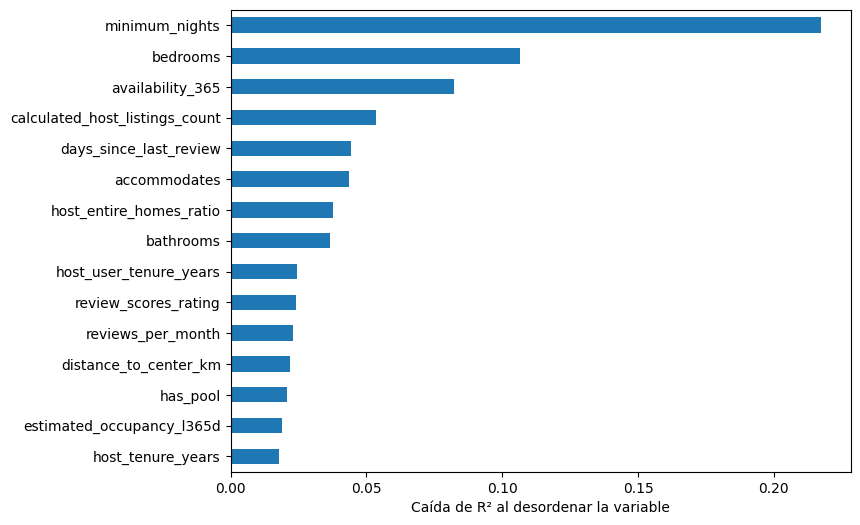

In [20]:
plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Caída de R² al desordenar la variable")

### 10.2 Interpretación

**`minimum_nights` vuelve a dominar** (caída de R² de 0.217), el mismo patrón ya visto en las otras cuatro ciudades: un modelo de árboles aprovecha la relación no lineal "estancias largas más baratas por noche" mucho mejor que una correlación lineal simple. Le siguen `bedrooms` (0.107) y `availability_365` (0.082): a diferencia de las otras ciudades, aquí `accommodates` (0.044) queda relegado al sexto puesto, por detrás incluso de `calculated_host_listings_count` (0.054) y `days_since_last_review` (0.044).

Es un orden más disperso que en las otras ciudades (sin un trío tan dominante y separado del resto), coherente con todo lo visto hasta ahora: en Sevilla ninguna variable aislada explica gran parte del precio, la señal está más repartida entre muchas variables moderadas. `has_pool` (0.021) entra en el top 15 pese a su correlación débil en la EDA (0.052): un modelo no lineal puede aprovechar incluso una señal débil en interacción con otras variables.

### 10.3 SHAP: cuánto y en qué dirección

Se calcula sobre el test, igual que la importancia por permutación.

In [21]:
explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
shap_values = explainer(X_test)

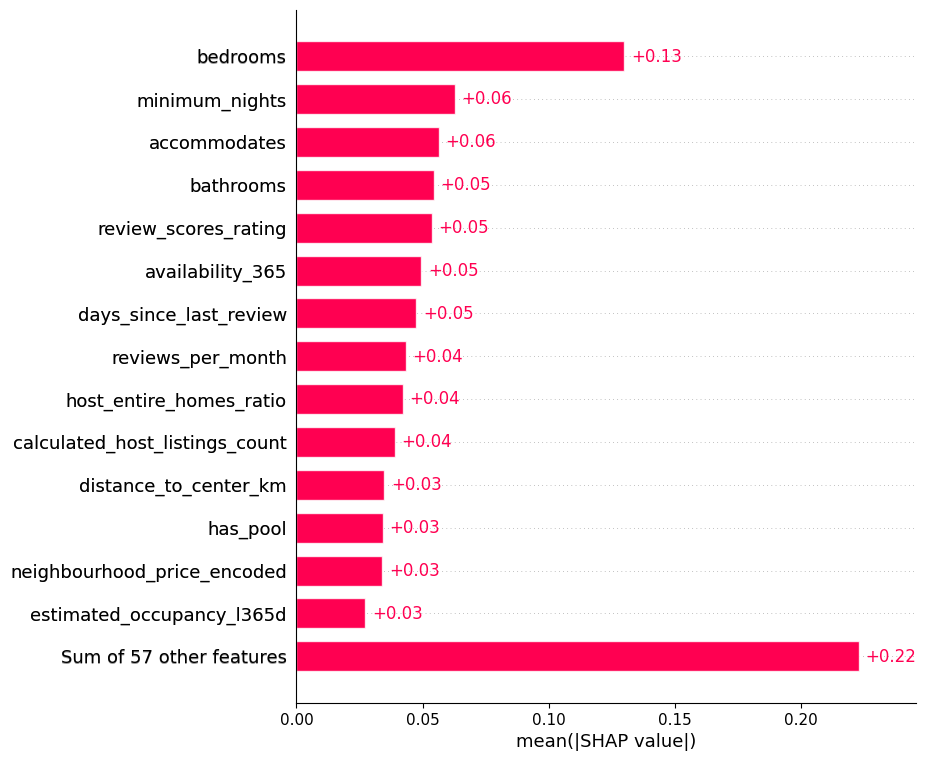

In [22]:
shap.plots.bar(shap_values, max_display=15)

Orden algo distinto al de la importancia por permutación: SHAP pone a `bedrooms` (0.130) muy por delante del resto, seguido de `minimum_nights` (0.063), `accommodates` (0.057) y `bathrooms` (0.055): las cuatro variables de tamaño juntas en el top 4, más agrupadas que en la permutación. `review_scores_rating` (0.054) y `availability_365` (0.049) completan un grupo intermedio. Que los dos métodos no coincidan en el orden exacto (permutación prioriza `minimum_nights`/`availability_365`, SHAP prioriza `bedrooms`/tamaño) es coherente con el hallazgo de la sección 10.2: la señal está repartida, no concentrada en una o dos variables dominantes, así que el orden exacto es sensible al método de medición.

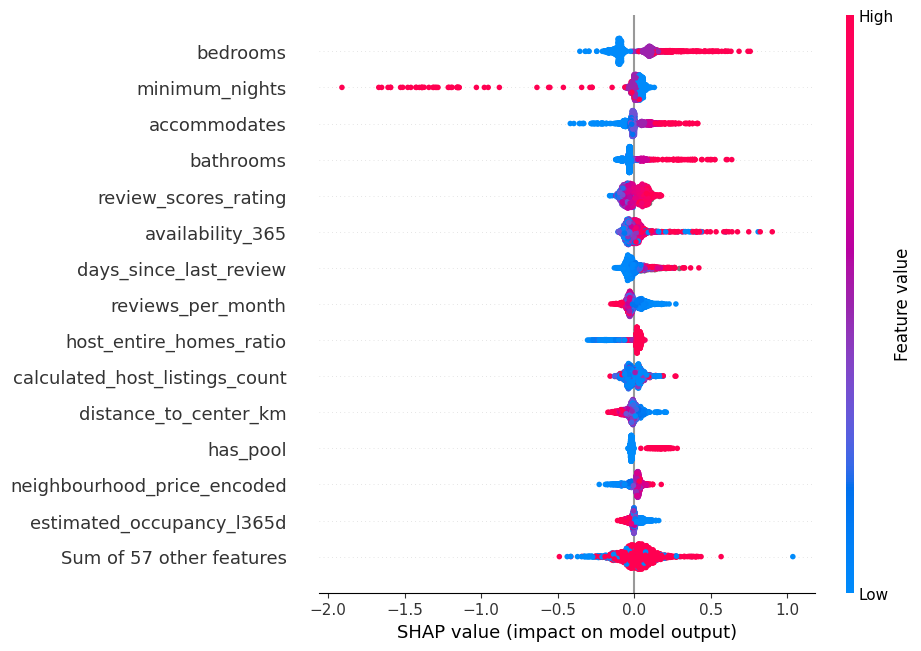

In [23]:
shap.plots.beeswarm(shap_values, max_display=15)

La dirección es la esperada en todos los casos: `bedrooms` (corr. valor↔SHAP 0.95), `accommodates` (0.91) y `bathrooms` (0.86) empujan el precio hacia arriba cuando son altos, el patrón de tamaño ya conocido. `minimum_nights` (-0.98) hace lo contrario con fuerza: valores altos empujan hacia abajo, el mismo patrón de "estancia larga más barata por noche" visto en las otras ciudades. `distance_to_center_km` (-0.74) también en la dirección esperada (más lejos del centro, precio más bajo), y `has_pool` (0.97) empuja hacia arriba con una consistencia mayor de lo que sugería su correlación bruta en la EDA (0.052): de nuevo, la señal existe y es consistente en dirección, solo que es débil en magnitud media. `calculated_host_listings_count` es la excepción: pesa bastante en la importancia por permutación (0.054) pero su relación con el SHAP es casi plana (corr. 0.03), señal de un efecto no monótono (quizá relevante en combinación con otras variables, no por su valor aislado).

### 10.4 Un ejemplo concreto

Se elige un anuncio de precio cercano a la mediana del test, y donde además el modelo acierta bastante.

Precio real: 126.00€, predicho: 131.50€


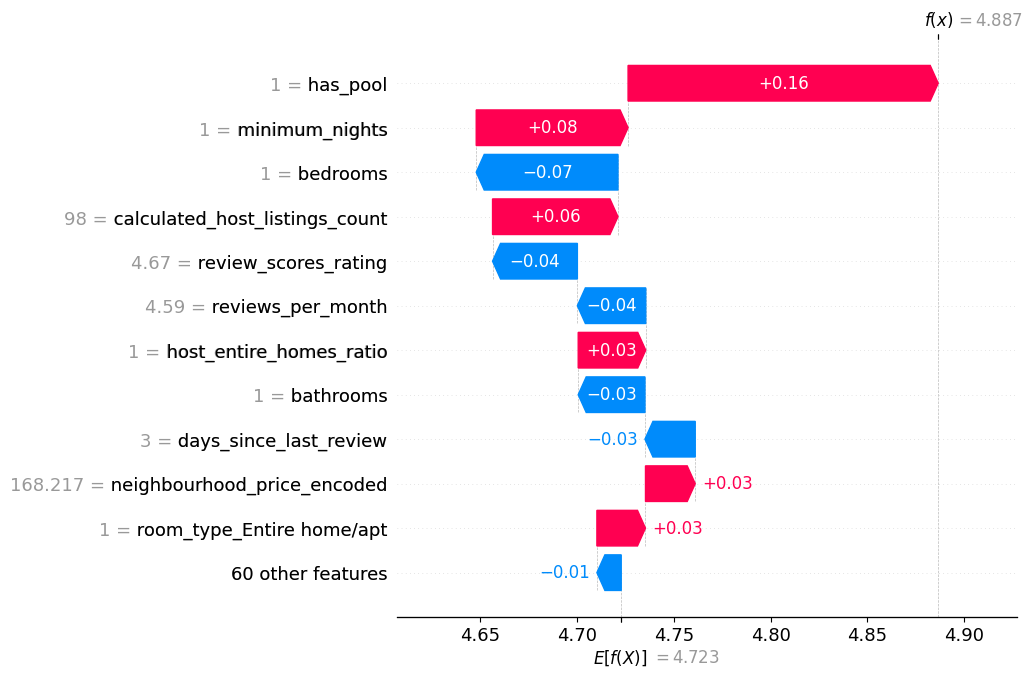

In [24]:
pred_test_all = np.expm1(final_pipeline.predict(X_test))
error_test = pred_test_all - y_test.values
median_price = y_test.median()

candidate_mask = (np.abs(y_test.values - median_price) < 20) & (np.abs(error_test) < 10)
example_pos = np.where(candidate_mask)[0][0]

print(f"Precio real: {y_test.iloc[example_pos]:.2f}€, predicho: {pred_test_all[example_pos]:.2f}€")
shap.plots.waterfall(shap_values[example_pos], max_display=12)

El valor base (`E[f(X)]`) equivale a unos 111€. Para este anuncio en concreto (piso entero para 4 personas, 1 dormitorio, 1 baño, `minimum_nights=1`, con piscina, disponible 316 días al año, en un barrio algo por encima de la media de precio): `has_pool=1` empuja el precio hacia arriba con más fuerza que ninguna otra variable, `minimum_nights=1` (sin exigir estancia larga) y `calculated_host_listings_count` también lo empujan hacia arriba, mientras que `bedrooms=1` (por debajo de lo típico para 4 personas) y `review_scores_rating` lo empujan ligeramente hacia abajo, hasta llegar a la predicción final de 131.50€ (el precio real era 126€, un acierto razonable). El mismo tipo de desglose que en las otras ciudades: "tu precio sube sobre todo por tener piscina y no exigir estancia mínima larga, pero baja un poco por tener solo 1 dormitorio para 4 personas".

## 11. Guardar el modelo

Guardar el modelo final entrenado (con `joblib`) en `models/sevilla/`, para que `05_model_evaluation.ipynb` lo cargue directamente.

### 11.1 El modelo

In [25]:
import joblib

joblib.dump(final_pipeline, f"{PROJECT_DIR}/models/sevilla/price_model.pkl")

['/Users/yagocoll/Documents/Master/Airbnb/models/sevilla/price_model.pkl']

### 11.2 Metadatos

Se guarda todo lo que `05_model_evaluation.ipynb` necesitará saber sin releer este notebook entero.

In [26]:
import json
from datetime import date

metadata = {
    "model": "HistGradientBoostingRegressor",
    "date": str(date.today()),
    "target": target_col,
    "id_cols": id_cols,
    "leakage_cols_excluded": leakage_cols,
    "feature_cols": feature_cols,
    "best_params": {k.replace("model__", ""): v for k, v in hgb_search.best_params_.items()},
    "test_metrics": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
    "baseline_metrics": {"model": "Regresión lineal", "RMSE": 289.82, "MAE": 62.55, "R2": 0.06, "MAPE": 30.25},
}


metadata["test_metrics"]["R2_log"] = float(r2_score(y_test_log, final_pipeline.predict(X_test)))
with open(f"{PROJECT_DIR}/models/sevilla/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

metadata

{'model': 'HistGradientBoostingRegressor',
 'date': '2026-09-09',
 'target': 'price',
 'id_cols': ['id', 'host_id', 'host_profile_id'],
 'leakage_cols_excluded': ['price_log',
  'price_per_accommodate',
  'price_per_min_night'],
 'feature_cols': ['host_is_superhost',
  'host_has_profile_pic',
  'host_identity_verified',
  'latitude',
  'longitude',
  'accommodates',
  'bathrooms',
  'bedrooms',
  'beds',
  'minimum_nights',
  'maximum_nights',
  'availability_365',
  'number_of_reviews',
  'number_of_reviews_ltm',
  'estimated_occupancy_l365d',
  'review_scores_rating',
  'calculated_host_listings_count',
  'reviews_per_month',
  'has_license',
  'number_of_reviews_log',
  'number_of_reviews_ltm_log',
  'reviews_per_month_log',
  'bedrooms_log',
  'beds_log',
  'bathrooms_log',
  'calculated_host_listings_count_log',
  'room_type_Entire home/apt',
  'room_type_Hotel room',
  'room_type_Private room',
  'room_type_Shared room',
  'district_Casco Antiguo',
  'district_Cerro - Amate',
  '

`R2_log` (0.60) es el R² calculado sobre `log1p(price)`, la escala en la que el modelo realmente entrena, mucho más alto que el R² en euros (0.17), la brecha más grande de las cinco ciudades, precisamente porque en euros pesan muchísimo los precios extremos que se vieron desde la sección 8.2 de `03_model_baseline.ipynb`. Se guarda como métrica adicional para que la app pueda mostrar una cifra de "cuánto explica el modelo" comparable entre ciudades.

## 12. Conclusiones

Resumen de qué modelo ganó, cuánto mejora sobre el baseline, y qué variables resultaron más importantes.

### El proceso, resumido

1. Se probaron 4 tipos de modelo con hiperparámetros por defecto. Los cuatro quedaron muy apretados y bajos en euros (R² 0.09-0.13), con Hist Gradient Boosting ligeramente por delante.
2. Se afinaron los tres modelos de árboles. En escala logarítmica, la mejora fue notable (hasta R²≈0.58). En euros, apenas se movió la aguja (R² 0.10-0.13), la subida más pequeña de las cinco ciudades. Hist Gradient Boosting ganó con claridad en las cuatro métricas (a diferencia del empate técnico de Valencia).
3. El modelo final se evaluó en test una única vez.

### Resultado final

| Modelo | RMSE | MAE | R² | MAPE |
|---|---|---|---|---|
| Regresión lineal (baseline) | 289.82€ | 62.55€ | 0.06 | 30.25% |
| **Hist Gradient Boosting (final)** | **272.82€** | **56.28€** | **0.17** | **26.85%** |

Mejora real sobre el baseline en las cuatro métricas, pero el R² sigue siendo, con diferencia, el más bajo de las cinco ciudades. Comparado también contra train (sección 8.2): aquí sí aparece sobreajuste claro (R² 0.58 en train frente a 0.17 en test), a diferencia del caso inverso visto en Valencia: con 71 features sobre un dataset de tamaño medio y una variable objetivo de cola extremadamente larga, el modelo tiene margen de sobra para ajustarse a particularidades del train que no generalizan igual de bien.

### Qué explica el precio, según el modelo

Permutation importance y SHAP coinciden en que **el tamaño y `minimum_nights` dominan**, pero no se ponen de acuerdo en el orden exacto: la permutación prioriza `minimum_nights`/`bedrooms`/`availability_365`, SHAP prioriza `bedrooms`/`minimum_nights`/`accommodates`/`bathrooms`. Esta falta de acuerdo en el orden exacto (a diferencia del trío claro y consistente de las otras ciudades) es en sí misma un hallazgo: en Sevilla la señal está más repartida entre muchas variables moderadas, sin una o dos que dominen con claridad. `has_pool` aparece con una dirección muy consistente en SHAP pese a su correlación bruta débil en la EDA, y `calculated_host_listings_count` muestra un efecto no monótono (importante mas no lineal en su relación directa con el precio).

### Qué queda pendiente

- El análisis de errores más detallado se deja para `05_model_evaluation.ipynb`, que parte de `models/sevilla/price_model.pkl` y `models/sevilla/model_metadata.json` ya guardados aquí.
- Dado el hallazgo de `03_model_baseline.ipynb` (varianza alta del split frente a la cola larga de `price`, aquí confirmada con el sobreajuste de la sección 8.2), sería especialmente importante que `05_model_evaluation.ipynb` revise el error específicamente en los anuncios de precio muy alto y en los de tamaño atípico, en vez de fiarse solo del R²/RMSE agregado de un único split: Sevilla es, de las cinco ciudades, la que más lo necesita.